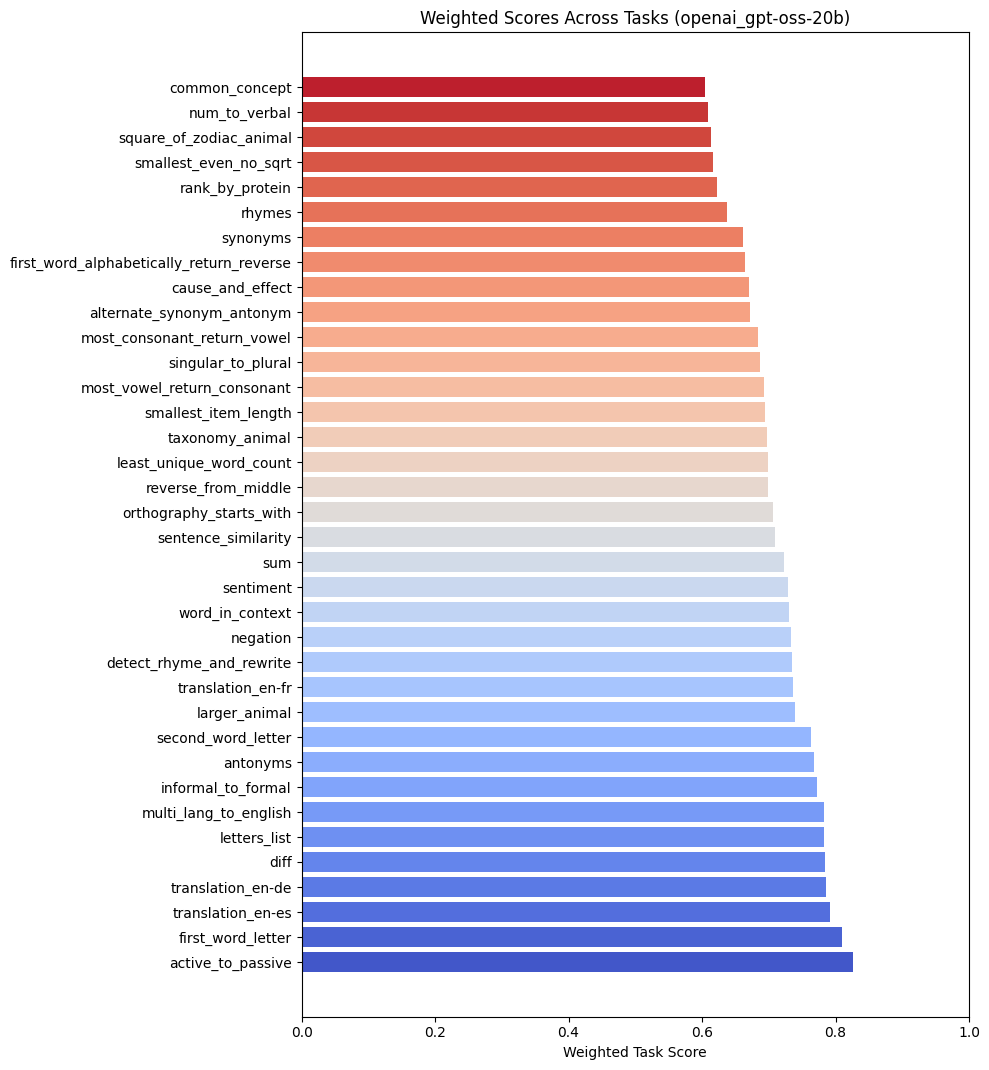

Visualization saved to: predictions_openai_gpt-oss-20b/visualizations/task_scores.pdf


In [43]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


model_labels = {}
model_labels["nvidia_Nemotron-Research-Reasoning-Qwen-1.5B"] = "NRR"
model_labels["open-thoughts_OpenThinker-7B"] = "OpenT"
model_labels["openai_gpt-oss-20b"] = "OSS"
model_labels["Qwen_QwQ-32B"] = "QwQ"

def viz_scores(folder_path, vis_folder = "visualizations"):
    # Extract model name from folder
    model_name = os.path.basename(folder_path).replace("predictions_", "")
    
    # Path to save visualizations
    os.makedirs(vis_folder, exist_ok=True)
    
    # Collect task scores
    task_scores = []
    for filename in os.listdir(folder_path):
        if filename.endswith("_with_scores.json"):
            # Extract task name without model
            task_name = filename.replace("_with_scores.json", "")
            file_path = os.path.join(folder_path, filename)
            with open(file_path, "r") as f:
                data = json.load(f)
                score = data.get("weighted_task_score")
                if score is not None:
                    task_scores.append((task_name, score))
    
    # Convert to DataFrame and sort
    df = pd.DataFrame(task_scores, columns=["Task", "Weighted Score"])
    df = df.sort_values(by="Weighted Score", ascending=False)
    
    # Visualization
    plt.figure(figsize=(10, max(6, len(df) * 0.3)))
    colors = sns.color_palette("coolwarm", len(df))
    plt.barh(df["Task"], df["Weighted Score"], color=colors)
    plt.xlim(0, 1)
    plt.xlabel("Weighted Task Score")
    plt.title(f"Weighted Scores Across Tasks ({model_name})")
    plt.tight_layout()
    
    # Save figure as PDF
    fig_path = os.path.join(vis_folder, f"{model_labels[model_name]}_task_scores.pdf")
    plt.savefig(fig_path, format='pdf', dpi=300)
    plt.show()

folder_path = "predictions_openai_gpt-oss-20b"
viz_scores(folder_path)
print(f"Visualization saved to: {fig_path}")
